Classificação K-MEANS utilizando a variável e-waste como alvo

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA


df = pd.read_csv("/content/Global_Tech_Gadget_Consumption.csv")



In [8]:
# ---------------------------------------------------
# 2. TRANSFORMAR 'E-WASTE GENERATED' EM CATEGORIAS
# ---------------------------------------------------
# Criar 3 classes usando cortes pelos quantis
df["EWaste_Class"] = pd.qcut(df["E-Waste Generated (Metric Tons)"],
                             q=3,
                             labels=["Baixo", "Medio", "Alto"])

# Transformar em números
df["EWaste_Class"] = df["EWaste_Class"].astype("category").cat.codes

# Definir variável alvo
target = "EWaste_Class"

In [10]:
# ---------------------------------------------------
# 3. SEPARAR FEATURES E ALVO
# ---------------------------------------------------

# Remover o alvo, a coluna original contínua e a coluna 'Country' (que é categórica)
X = df.drop(columns=["EWaste_Class", "E-Waste Generated (Metric Tons)", "Country"])
y = df[target]

# Normalizar
symmetric_scaler = StandardScaler()
X_scaled = symmetric_scaler.fit_transform(X)

# ---------------------------------------------------

StandardScaler só aceita números (teve de normalizar Country)

In [11]:
# 4. TREINAR K-MEANS
# ---------------------------------------------------

k = len(df[target].unique())   # 3 classes (baixo, médio, alto)
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)


In [12]:

# 5. MAPEAR CLUSTERS PARA CLASSES REAIS
# ---------------------------------------------------
mapping = {}
for c in np.unique(clusters):
    mask = clusters == c
    most_common = y[mask].mode()[0]
    mapping[c] = most_common

predicted = [mapping[c] for c in clusters]




Acurácia: 0.4

Matriz de Confusão:
 [[18  0 19]
 [16  0 20]
 [11  0 26]]


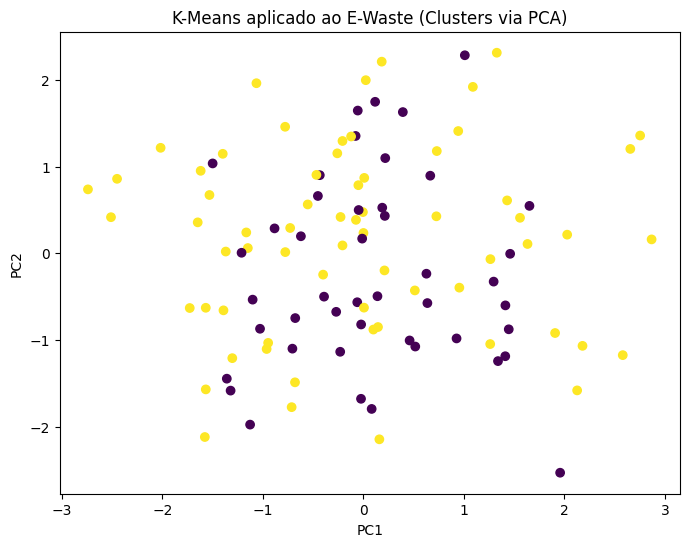

In [13]:

# 6. AVALIAÇÃO DO MODELO
# ---------------------------------------------------

acc = accuracy_score(y, predicted)
cm = confusion_matrix(y, predicted)

print("\nAcurácia:", round(acc, 4))
print("\nMatriz de Confusão:\n", cm)

# ---------------------------------------------------
# 7. VISUALIZAÇÃO COM PCA
# ---------------------------------------------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=predicted, cmap="viridis")
plt.title("K-Means aplicado ao E-Waste (Clusters via PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**Análise dos resultados obtidos**

O algoritmo K-Means foi aplicado com o objetivo de classificar as observações em três categorias de geração de e-waste (baixo, médio e alto). A acurácia obtida pelo modelo foi de 0,40, indicando que aproximadamente 40% das classificações feitas pelo algoritmo coincidiram com os rótulos atribuídos.

Esse desempenho relativamente baixo é esperado devido às características do método utilizado. O K-Means é um algoritmo não supervisionado, portanto ele forma agrupamentos com base exclusivamente na estrutura interna dos dados, sem acesso às classes verdadeiras durante o processo de treinamento. Isso significa que, caso as categorias de e-waste não representem agrupamentos naturalmente presentes no conjunto de variáveis analisadas, o modelo tende a apresentar dificuldades em reproduzir exatamente os rótulos definidos.

A matriz de confusão obtida confirma essa interpretação, apresentando um número expressivo de classificações cruzadas entre as três classes. Isso sugere que as observações correspondentes aos níveis baixo, médio e alto de e-waste não formam grupos bem separados no espaço das variáveis utilizadas. Em outras palavras, embora o dataset contenha informações relevantes sobre consumo, investimento e tecnologia, tais atributos não se organizam de forma natural em três blocos distintos que correspondam diretamente aos níveis categorizados de geração de e-waste.

Portanto, os resultados refletem principalmente a disposição real dos dados, e não uma falha no algoritmo. Como não há separação clara entre os níveis de e-waste nas variáveis consideradas, o K-Means tende a apresentar desempenho limitado nesse tipo de tarefa. Ainda assim, o modelo fornece uma visão importante sobre a estrutura interna do dataset e evidencia a ausência de agrupamentos naturais compatíveis com as categorias definidas.